In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

import mlflow
from mlflow.models import infer_signature
from mlflow.tracking import MlflowClient
from dotenv import load_dotenv

from sklearn import set_config
set_config(transform_output="pandas")

from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import TargetEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, root_mean_squared_error as rmse, mean_absolute_percentage_error as mape

print("Библиотеки загружены")

Библиотеки загружены


In [2]:
load_dotenv()

df = pd.read_excel("../data/moscow_transformed.xlsx").set_index(["ID на сайте", "Источник"])

df = df[["Цена", "lat", "lng", "Общая площадь", "Расстояние до метро, км", 
         "Этаж", "Тип автора", "Вид объекта", "Метро/Район"]].copy()

df.columns = ["price", "lat", "lon", "square", "metro_dist", "floor", 
              "author_type", "object_type", "metro_district"]

df = df.dropna(subset="object_type")

print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} колонок")
print(f"Колонки: {list(df.columns)}")

display(df.head())
print(df.info())
display(df.describe())

Размер датасета: 9069 строк, 9 колонок
Колонки: ['price', 'lat', 'lon', 'square', 'metro_dist', 'floor', 'author_type', 'object_type', 'metro_district']


,,price,lat,lon,square,metro_dist,floor,author_type,object_type,metro_district
ID на сайте,Источник,,,,,,,,,
320731003,cian.ru,38800,55.621211,37.745600,25.0,0.083,4.0,Агентство,Офисное помещение,Шипиловская
321876001,cian.ru,31250,55.799036,37.532601,25.0,0.250,-2.0,Агентство,Офисное помещение,Аэропорт
322186790,cian.ru,29200,55.731176,37.669279,20.0,0.250,6.0,Агентство,Офисное помещение,Пролетарская
321392086,cian.ru,32000,55.540409,37.516153,32.0,0.250,3.0,Частное лицо,Торговое / Свободного назначения,Бунинская Аллея
324943206,cian.ru,44000,55.808002,37.635853,24.0,0.167,14.0,Агентство,Офисное помещение,Алексеевская


<class 'pandas.core.frame.DataFrame'>
MultiIndex: 9069 entries, (np.int64(320731003), 'cian.ru') to (np.int64(3940063262435014144), 'realty.yandex.ru')
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   price           9069 non-null   int64  
 1   lat             9069 non-null   float64
 2   lon             9069 non-null   float64
 3   square          9069 non-null   float64
 4   metro_dist      9069 non-null   float64
 5   floor           8946 non-null   float64
 6   author_type     9069 non-null   object 
 7   object_type     9069 non-null   object 
 8   metro_district  9069 non-null   object 
dtypes: float64(5), int64(1), object(3)
memory usage: 988.9+ KB
None


,price,lat,lon,square,metro_dist,floor
count,9.069000e+03,9069.000000,9069.000000,9069.000000,9069.000000,8946.000000
mean,1.155942e+06,55.737563,37.586329,343.737004,1.326039,4.199419
std,1.437653e+06,0.070116,0.095460,388.142146,2.551788,7.078117
min,1.250000e+04,55.429021,37.113959,20.000000,0.083000,-2.000000
25%,2.335500e+05,55.701303,37.532601,79.000000,0.417000,1.000000
50%,5.588730e+05,55.747078,37.599365,184.000000,0.750000,2.000000
75%,1.491435e+06,55.781691,37.641960,461.000000,1.167000,5.000000
max,7.996698e+06,55.997598,37.948898,1995.000000,37.583000,81.000000


Train размер: 6801 объектов
Test размер: 2268 объектов


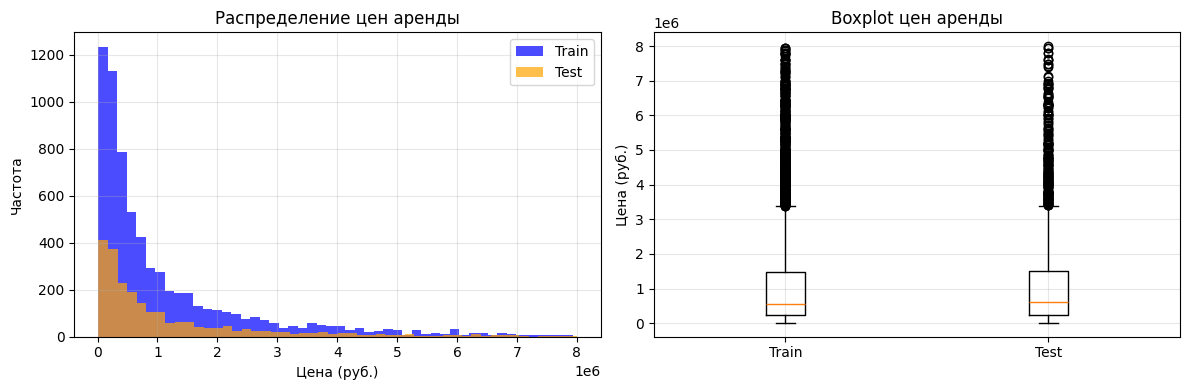

In [3]:
y = df["price"].copy()
X = df.drop("price", axis=1)

df_train, df_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=df["object_type"], random_state=42
)

df_train["floor"] = df_train["floor"].fillna(1)
df_test["floor"] = df_test["floor"].fillna(1)

print(f"Train размер: {df_train.shape[0]} объектов")
print(f"Test размер: {df_test.shape[0]} объектов")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y_train, bins=50, alpha=0.7, label='Train', color='blue')
axes[0].hist(y_test, bins=50, alpha=0.7, label='Test', color='orange')
axes[0].set_title('Распределение цен аренды')
axes[0].set_xlabel('Цена (руб.)')
axes[0].set_ylabel('Частота')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].boxplot([y_train, y_test], labels=['Train', 'Test'])
axes[1].set_title('Boxplot цен аренды')
axes[1].set_ylabel('Цена (руб.)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [4]:
class OrdinalByTargetEncoder(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.te = TargetEncoder(target_type="continuous", random_state=42)
        self.cat_mappings = {}
        self.median_values = {}
        
    def fit(self, X, y):
        self.te.fit(X, y)
        
        for i, col in enumerate(X.columns):
            cat_dict = dict(zip(self.te.categories_[i], self.te.encodings_[i]))
            ordinal_categories = sorted(cat_dict, key=cat_dict.get)
            self.cat_mappings[col] = dict(zip(ordinal_categories, range(len(ordinal_categories))))
            self.median_values[col] = len(ordinal_categories) // 2
        
        return self
        
    def transform(self, X, y=None):
        X_copy = X.copy()
        
        for col in X.columns:
            if col in self.cat_mappings:
                X_copy[col] = X_copy[col].map(self.cat_mappings[col])
                X_copy[col] = X_copy[col].fillna(self.median_values[col])
        
        return X_copy

    def fit_transform(self, X, y):
        return self.fit(X, y).transform(X)

    def set_output(self, *, transform=None):
        return self

print("OrdinalByTargetEncoder создан")

OrdinalByTargetEncoder создан


In [5]:
def make_transformer(scale_cols: list, one_hot_cols: list, ordinal_cols: list, **kwargs):
    ct = ColumnTransformer(
        transformers=[
            ("scale", StandardScaler(), scale_cols),
            ("onehot", OneHotEncoder(drop="if_binary", sparse_output=False), one_hot_cols),
            ("ordinal", OrdinalByTargetEncoder(), ordinal_cols),
        ],
        **kwargs
    ).set_output(transform="pandas")
    return ct

def make_pipeline(model, scale_cols: list, one_hot_cols: list, ordinal_cols: list, **kwargs):
    ct = make_transformer(scale_cols, one_hot_cols, ordinal_cols, **kwargs)
    pipe = Pipeline(steps=[("transformer", ct), ("model", model)])
    return pipe

print("Функции для создания pipeline готовы")

Функции для создания pipeline готовы


In [6]:
scale_cols = ["square", "metro_dist", "floor"]
one_hot_cols = ["object_type", "author_type"]
ordinal_cols = ["metro_district"]

linear_pipe = make_pipeline(
    LinearRegression(),
    scale_cols, one_hot_cols, ordinal_cols,
    remainder="passthrough", n_jobs=-1
)

model = linear_pipe.fit(df_train, y_train)
y_pred = model.predict(df_train)
y_test_pred = model.predict(df_test)

def print_metrics(y_true, y_pred, dataset):
    print(f"{dataset} metrics:")
    print(f"  R2: {r2_score(y_true, y_pred) * 100:.2f}%")
    print(f"  RMSE: {rmse(y_true, y_pred):.2f} руб.")
    print(f"  MAPE: {mape(y_true, y_pred) * 100:.2f}%")

print_metrics(y_train, y_pred, "train")
print()
print_metrics(y_test, y_test_pred, "test")

train metrics:
  R2: 72.83%
  RMSE: 746945.35 руб.
  MAPE: 93.21%

test metrics:
  R2: 73.82%
  RMSE: 742602.96 руб.
  MAPE: 94.22%


In [7]:
import mlflow
from mlflow.tracking import MlflowClient

# Устанавливаем URI удаленного MLflow сервера
mlflow.set_tracking_uri("https://sirius-mlflow.onrender.com")
print(f"MLflow версия: {mlflow.__version__}")
print(f"Tracking URI: {mlflow.get_tracking_uri()}")

# Проверяем доступность сервера
try:
    client = MlflowClient()
    experiments = client.search_experiments()
    print(f"Сервер доступен. Экспериментов: {len(experiments)}")
except Exception as e:
    print(f"Ошибка подключения: {e}")

# Устанавливаем эксперимент
mlflow.set_experiment(experiment_id="0")
print("Эксперимент установлен: 0")

MLflow версия: 3.8.0
Tracking URI: https://sirius-mlflow.onrender.com
Сервер доступен. Экспериментов: 1
Эксперимент установлен: 0


In [8]:
# Ячейка для логирования модели
run_description = "Прогноз арендной платы коммерческой недвижимости в Москве"

try:
    with mlflow.start_run(run_name="moscow-rent-linear", description=run_description) as run:
        print(f"Run начат: {run.info.run_id}")
        
        # 1. Логируем модель БЕЗ registered_model_name
        print("Логирую модель...")
        mlflow.sklearn.log_model(
            sk_model=linear_pipe, 
            artifact_path="model"
        )
        print("Модель залогирована")
        
        # 2. Логируем параметры
        print("Логирую параметры...")
        mlflow.log_param("model_type", "LinearRegression")
        mlflow.log_param("scale_cols", ", ".join(scale_cols))
        mlflow.log_param("one_hot_cols", ", ".join(one_hot_cols))
        mlflow.log_param("ordinal_cols", ", ".join(ordinal_cols))
        mlflow.log_param("n_features", df_train.shape[1])
        mlflow.log_param("n_train", df_train.shape[0])
        mlflow.log_param("n_test", df_test.shape[0])
        
        # 3. Логируем метрики
        print("Логирую метрики...")
        
        # Train metrics
        mlflow.log_metric("train_r2", r2_score(y_train, y_pred))
        mlflow.log_metric("train_rmse", rmse(y_train, y_pred))
        mlflow.log_metric("train_mape", mape(y_train, y_pred))
        
        # Test metrics
        mlflow.log_metric("test_r2", r2_score(y_test, y_test_pred))
        mlflow.log_metric("test_rmse", rmse(y_test, y_test_pred))
        mlflow.log_metric("test_mape", mape(y_test, y_test_pred))
        
        # 4. Добавляем теги
        mlflow.set_tag("project", "sirius-school-proj")
        mlflow.set_tag("author", "malyk")
        mlflow.set_tag("model_name", "moscow-rent-prediction")
        
        print(f"Логирование завершено!")
        print(f"Run ID: {run.info.run_id}")
        print(f"Ссылка: https://sirius-mlflow.onrender.com/#/experiments/0/runs/{run.info.run_id}")
        
except Exception as e:
    print(f"Ошибка: {e}")
    import traceback
    traceback.print_exc()

2025/12/25 10:13:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Run начат: cfb7e261563d45e98b4a25f57f90aeb5
Логирую модель...
🏃 View run moscow-rent-linear at: https://sirius-mlflow.onrender.com/#/experiments/0/runs/cfb7e261563d45e98b4a25f57f90aeb5
🧪 View experiment at: https://sirius-mlflow.onrender.com/#/experiments/0
Ошибка: API request to endpoint /api/2.0/mlflow/logged-models failed with error code 404 != 200. Response body: '<!doctype html>
<html lang=en>
<title>404 Not Found</title>
<h1>Not Found</h1>
<p>The requested URL was not found on the server. If you entered the URL manually please check your spelling and try again.</p>
'


Traceback (most recent call last):
  File "C:\Users\malyk\AppData\Local\Temp\ipykernel_31796\822114615.py", line 10, in <module>
    mlflow.sklearn.log_model(
    ~~~~~~~~~~~~~~~~~~~~~~~~^
        sk_model=linear_pipe,
        ^^^^^^^^^^^^^^^^^^^^^
        artifact_path="model"
        ^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "C:\Users\malyk\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\sklearn\__init__.py", line 426, in log_model
    return Model.log(
           ~~~~~~~~~^
        artifact_path=artifact_path,
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    ...<18 lines>...
        model_id=model_id,
        ^^^^^^^^^^^^^^^^^^
    )
    ^
  File "C:\Users\malyk\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\models\model.py", line 1161, in log
    model = _create_logged_model(
        # TODO: Update model name
    ...<7 lines>...
        flavor=flavor_name,
    )
  File "C:\Users\malyk\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\trackin

In [9]:
import mlflow
from mlflow.tracking import MlflowClient

mlflow.set_tracking_uri("https://sirius-mlflow.onrender.com")
mlflow.set_experiment(experiment_id="0")

# Явно указываем версию API сервера (например, 2.0.0, как видно в UI)
# Это может помочь клиенту использовать правильные эндпоинты.
# Но в данном случае, проблема именно в конкретном эндпоинте '/logged-models'

# Запускаем новый run, так как предыдущий завершился с ошибкой
with mlflow.start_run(run_name="moscow-rent-linear-v2") as run:
    print(f"Run начат: {run.info.run_id}")
    
    # 1. Сохраняем модель локально и логируем как файл-артефакт
    # Это старый и надежный способ, который точно работает
    import tempfile
    import joblib
    import os
    
    with tempfile.TemporaryDirectory() as tmpdir:
        model_path = os.path.join(tmpdir, "model.pkl")
        # Сохраняем вашу обученную модель 'linear_pipe'
        joblib.dump(linear_pipe, model_path)
        
        # Логируем файл как артефакт
        mlflow.log_artifact(model_path, artifact_path="model")
        print("Модель сохранена как артефакт 'model/model.pkl'")
    
    # 2. Логируем параметры отдельно
    mlflow.log_param("model_type", "LinearRegression")
    mlflow.log_param("n_features", df_train.shape[1])
    
    # 3. Логируем метрики
    mlflow.log_metric("test_r2", r2_score(y_test, y_test_pred))
    mlflow.log_metric("test_rmse", rmse(y_test, y_test_pred))
    
    # 4. Добавляем теги для поиска
    mlflow.set_tag("author", "malyk")
    mlflow.set_tag("project", "rent-prediction")
    
    print(f"Модель и метрики залогированы.")
    print(f"Ссылка на новый run: https://sirius-mlflow.onrender.com/#/experiments/0/runs/{run.info.run_id}")

Run начат: fdf951ea31504c96a73dbc84ede6da29
Модель сохранена как артефакт 'model/model.pkl'
Модель и метрики залогированы.
Ссылка на новый run: https://sirius-mlflow.onrender.com/#/experiments/0/runs/fdf951ea31504c96a73dbc84ede6da29
🏃 View run moscow-rent-linear-v2 at: https://sirius-mlflow.onrender.com/#/experiments/0/runs/fdf951ea31504c96a73dbc84ede6da29
🧪 View experiment at: https://sirius-mlflow.onrender.com/#/experiments/0


In [10]:
# Проверяем, что модель зарегистрирована
try:
    client = MlflowClient()
    
    # 1. Проверяем runs
    runs = mlflow.search_runs(experiment_ids=["0"])
    print(f"Всего runs в эксперименте 0: {len(runs)}")
    
    if len(runs) > 0:
        latest_run = runs.iloc[0]
        print(f"Последний run: {latest_run['run_id']}")
        print(f"Метрики: R2={latest_run['metrics.test_r2']:.3f}, RMSE={latest_run['metrics.test_rmse']:.0f}")
    
    # 2. Проверяем зарегистрированные модели
    print("\nЗарегистрированные модели:")
    models = client.search_registered_models()
    for model in models:
        print(f"  - {model.name}")
        for version in model.latest_versions:
            print(f"    Версия {version.version} (стадия: {version.current_stage})")
            
except Exception as e:
    print(f"Ошибка при проверке: {e}")

Всего runs в эксперименте 0: 7
Последний run: fdf951ea31504c96a73dbc84ede6da29
Метрики: R2=0.738, RMSE=742603

Зарегистрированные модели:


In [11]:
def get_rent_prediction(data: dict):
    X = pd.DataFrame([data])
    
    try:
        model = mlflow.sklearn.load_model("models:/moscow-rent-prediction/Production")
    except:
        model = mlflow.sklearn.load_model("models:/moscow-rent-prediction/latest")
    
    predicted_price = float(model.predict(X)[0])
    
    if hasattr(model.named_steps['model'], 'coef_'):
        feature_importance = dict(zip(
            X.columns, 
            model.named_steps['model'].coef_.tolist()
        ))
    else:
        feature_importance = None
    
    confidence_interval = {
        "lower": predicted_price * 0.9,
        "upper": predicted_price * 1.1,
        "confidence_level": 0.9
    }
    
    return predicted_price, confidence_interval, feature_importance

print("Функция get_rent_prediction создана")

Функция get_rent_prediction создана


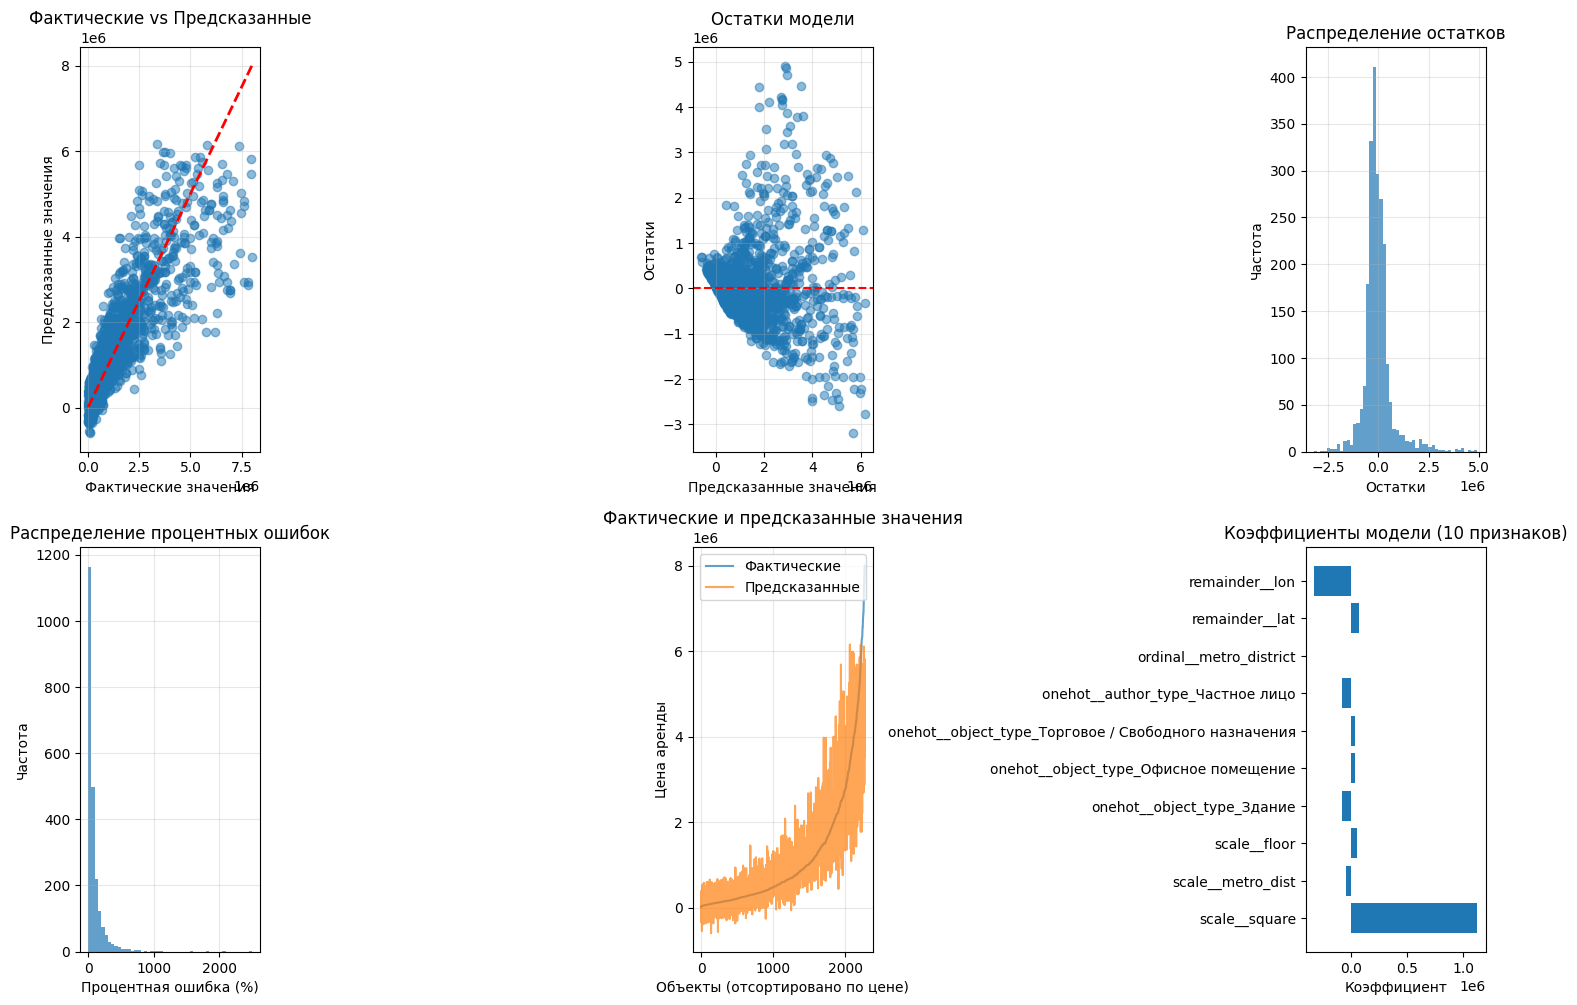

Визуализация завершена


In [13]:
# Ячейка 11: Визуализация результатов (ИСПРАВЛЕННАЯ)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# График 1: Фактические vs Предсказанные
axes[0, 0].scatter(y_test, y_test_pred, alpha=0.5)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Фактические значения')
axes[0, 0].set_ylabel('Предсказанные значения')
axes[0, 0].set_title('Фактические vs Предсказанные')
axes[0, 0].grid(True, alpha=0.3)

# График 2: Остатки
residuals = y_test - y_test_pred
axes[0, 1].scatter(y_test_pred, residuals, alpha=0.5)
axes[0, 1].axhline(y=0, color='r', linestyle='--')
axes[0, 1].set_xlabel('Предсказанные значения')
axes[0, 1].set_ylabel('Остатки')
axes[0, 1].set_title('Остатки модели')
axes[0, 1].grid(True, alpha=0.3)

# График 3: Распределение остатков
axes[0, 2].hist(residuals, bins=50, alpha=0.7)
axes[0, 2].set_xlabel('Остатки')
axes[0, 2].set_ylabel('Частота')
axes[0, 2].set_title('Распределение остатков')
axes[0, 2].grid(True, alpha=0.3)

# График 4: Процентные ошибки
percentage_errors = np.abs(residuals / y_test) * 100
axes[1, 0].hist(percentage_errors, bins=50, alpha=0.7)
axes[1, 0].set_xlabel('Процентная ошибка (%)')
axes[1, 0].set_ylabel('Частота')
axes[1, 0].set_title('Распределение процентных ошибок')
axes[1, 0].grid(True, alpha=0.3)

# График 5: Отсортированные значения
sorted_indices = np.argsort(y_test.values)
axes[1, 1].plot(y_test.values[sorted_indices], label='Фактические', alpha=0.7)
axes[1, 1].plot(y_test_pred[sorted_indices], label='Предсказанные', alpha=0.7)
axes[1, 1].set_xlabel('Объекты (отсортировано по цене)')
axes[1, 1].set_ylabel('Цена аренды')
axes[1, 1].set_title('Фактические и предсказанные значения')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# График 6: Важные признаки (ИСПРАВЛЕНО)
if hasattr(model.named_steps['model'], 'coef_'):
    coef = model.named_steps['model'].coef_
    # Получаем реальные имена признаков после трансформации
    try:
        # Попробуем получить финальные имена признаков
        transformed_train = model.named_steps['transformer'].fit_transform(df_train, y_train)
        feature_names = list(transformed_train.columns)
    except:
        # Если не получается, используем исходные имена
        feature_names = list(df_train.columns)
    
    # Берем все признаки, а не топ-10
    n_features = min(len(feature_names), len(coef))
    sorted_idx = np.argsort(np.abs(coef[:n_features]))
    
    # Используем все доступные признаки
    axes[1, 2].barh(range(n_features), coef[:n_features])
    axes[1, 2].set_yticks(range(n_features))
    axes[1, 2].set_yticklabels([feature_names[i] for i in range(n_features)])
    axes[1, 2].set_xlabel('Коэффициент')
    axes[1, 2].set_title(f'Коэффициенты модели ({n_features} признаков)')
else:
    axes[1, 2].text(0.5, 0.5, 'Нет коэффициентов\nдля визуализации', 
                    ha='center', va='center', transform=axes[1, 2].transAxes)
    axes[1, 2].set_title('Важность признаков')

plt.tight_layout()
plt.show()

print("Визуализация завершена")